In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage

In [4]:
df = pd.read_csv("iris.csv")

In [5]:
df.shape

(150, 6)

In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
df.drop('Id',axis=1,inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [9]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [10]:
df['Species']=df['Species'].map({'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2})

In [11]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
X = df.drop('Species', axis=1)

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

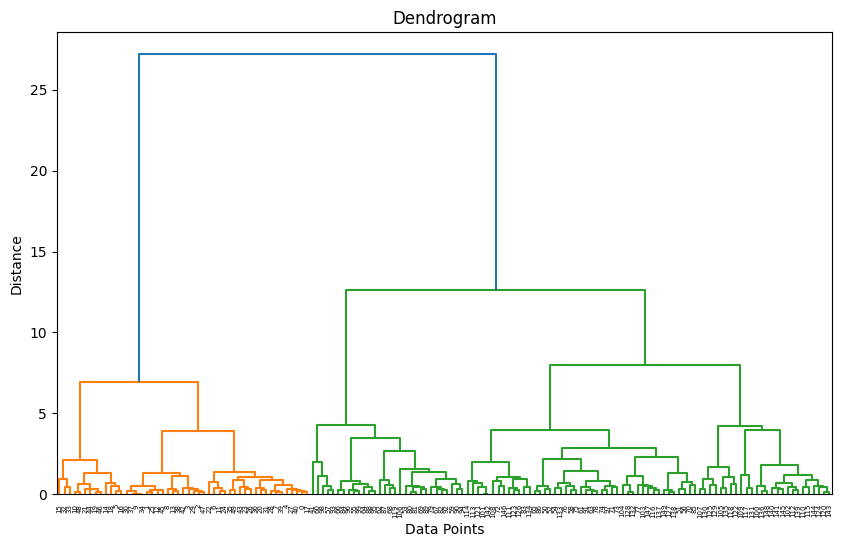

In [14]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))

dendrogram(Z)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [15]:
model = AgglomerativeClustering(n_clusters=3)
clusters = model.fit_predict(X_scaled)

In [16]:
df['Cluster']=clusters

In [17]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


In [20]:
df['Cluster'].value_counts()

Cluster
0    71
1    49
2    30
Name: count, dtype: int64

In [21]:
pd.crosstab(df['Species'], df['Cluster'])

Cluster,0,1,2
Species,,,
0,0,49,1
1,23,0,27
2,48,0,2


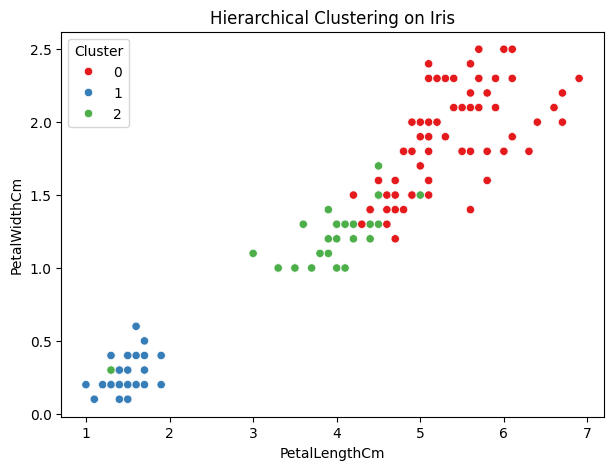

In [22]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df['PetalLengthCm'],
    y=df['PetalWidthCm'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Hierarchical Clustering on Iris")

plt.show()